In [137]:
pd.set_option('display.max_columns', None)

# --- Jupyter Notebook Cell ---

# 1. Imports
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# import all functions from all the modules in the code directory
from data_loader import *
from data_eda import *
from data_labels import *
from data_prep import *
from data_quality import *
from data_transform import *
from data_features import *

DATA_DIR = "/Users/saifali03/Desktop/SML/project/data/raw"

raw_df = load_and_merge_sessions(DATA_DIR)
df_no_gaps = trim_and_handle_gaps(raw_df)
df_imputed = handle_missing_values(df_no_gaps, missing_threshold=0.1)
df_final = construct_labels(df_imputed, temp_threshold_c=75.0)
verify_target_distribution(df_final)



2026-06-27 08:31:45,866 [INFO] Loaded mac_m5_20260625_001 with 211 rows.
2026-06-27 08:31:45,871 [INFO] Loaded mac_m5_20260626_001 with 2261 rows.
2026-06-27 08:31:45,875 [INFO] Loaded mac_m5_20260626_002 with 864 rows.
2026-06-27 08:31:45,877 [INFO] Loaded mac_m5_20260626_003 with 572 rows.
2026-06-27 08:31:45,883 [INFO] Loaded mac_m5_20260627_001 with 1346 rows.
2026-06-27 08:31:45,885 [INFO] Successfully merged 5 sessions. Total rows: 5254
2026-06-27 08:31:45,889 [INFO] Trimmed the first 5 and last 3 rows from all sessions.
2026-06-27 08:31:45,890 [INFO] Detected 6 temporal gaps exceeding 7 seconds after trimming.
2026-06-27 08:31:45,892 [INFO] Imputing gaps for 'cpu_die_temp_c' (Missing: 5.41%).
2026-06-27 08:31:45,896 [INFO] Constructing labels. Horizon: 1.0 min = 12 steps (window_size=13).
2026-06-27 08:31:45,898 [INFO] Dropped 60 tail rows with incomplete look-ahead windows.
2026-06-27 08:31:45,898 [INFO] Label construction complete. Class 1: 17.27% (890 / 5154 rows).


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Target Variable Distributions ---

Target: Y (binary label)
  Class 0: 4264 rows (82.73%)
  Class 1: 890 rows (17.27%)

Target: thermal_pressure_code
  Code 0.0: 5152 rows (99.96%)
  Code 1.0: 1 rows (0.02%)
  Code 2.0: 1 rows (0.02%)


In [138]:
df_final.columns

Index(['timestamp_utc', 'os_family', 'thermal_pressure_level',
       'thermal_pressure_code', 'cpu_die_temp_c', 'cpu_total_active_pct',
       'cpu_ecluster_active_pct', 'cpu_pcluster_active_pct',
       'cpu_ecluster_freq_mhz', 'cpu_pcluster_freq_mhz', 'gpu_active_pct',
       'cpu_power_mw', 'gpu_power_mw', 'combined_power_mw', 'loadavg_1m',
       'loadavg_5m', 'loadavg_15m', 'ram_used_gb', 'mem_pressure_pct',
       'mem_compressed_gb', 'session_id', 'Y'],
      dtype='str')

In [139]:
print_numeric_descriptive_stats(df_final)


--- Descriptive Statistics for Numeric Non-Binary Columns ---


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
thermal_pressure_code,5154.0,0.000582,0.031144,0.000000,0.000000,0.000000,0.000000,2.000000,0,0.0
cpu_die_temp_c,5154.0,46.947357,13.192415,29.702566,38.998187,41.268972,48.251115,80.596542,0,0.0
cpu_total_active_pct,5154.0,49.755366,18.281721,17.100800,36.604300,44.992450,60.410612,99.764385,0,0.0
cpu_ecluster_active_pct,5154.0,55.792112,13.341805,17.449500,47.658500,56.605400,64.466450,100.000000,0,0.0
cpu_pcluster_active_pct,5154.0,43.718621,28.659979,15.637800,22.113725,32.123000,52.333625,100.000000,0,0.0
cpu_ecluster_freq_mhz,5154.0,1678.921348,357.369563,1063.660000,1397.920000,1629.390000,1920.710000,2965.220000,0,0.0
cpu_pcluster_freq_mhz,5154.0,3668.832280,400.636180,2385.990000,3347.592500,3671.330000,4048.262500,4433.820000,0,0.0
gpu_active_pct,5154.0,11.758624,11.530592,0.051300,3.050350,8.454050,17.228100,82.730200,0,0.0
cpu_power_mw,5154.0,4787.367297,7279.340705,550.956000,904.985250,1260.435000,2747.762500,24804.100000,0,0.0
gpu_power_mw,5154.0,95.318773,124.014386,0.000000,12.169025,50.458900,128.710250,1467.080000,0,0.0


2026-06-27 08:31:51,539 [INFO] Generating KDE plots for 17 variables across a 6x3 grid.


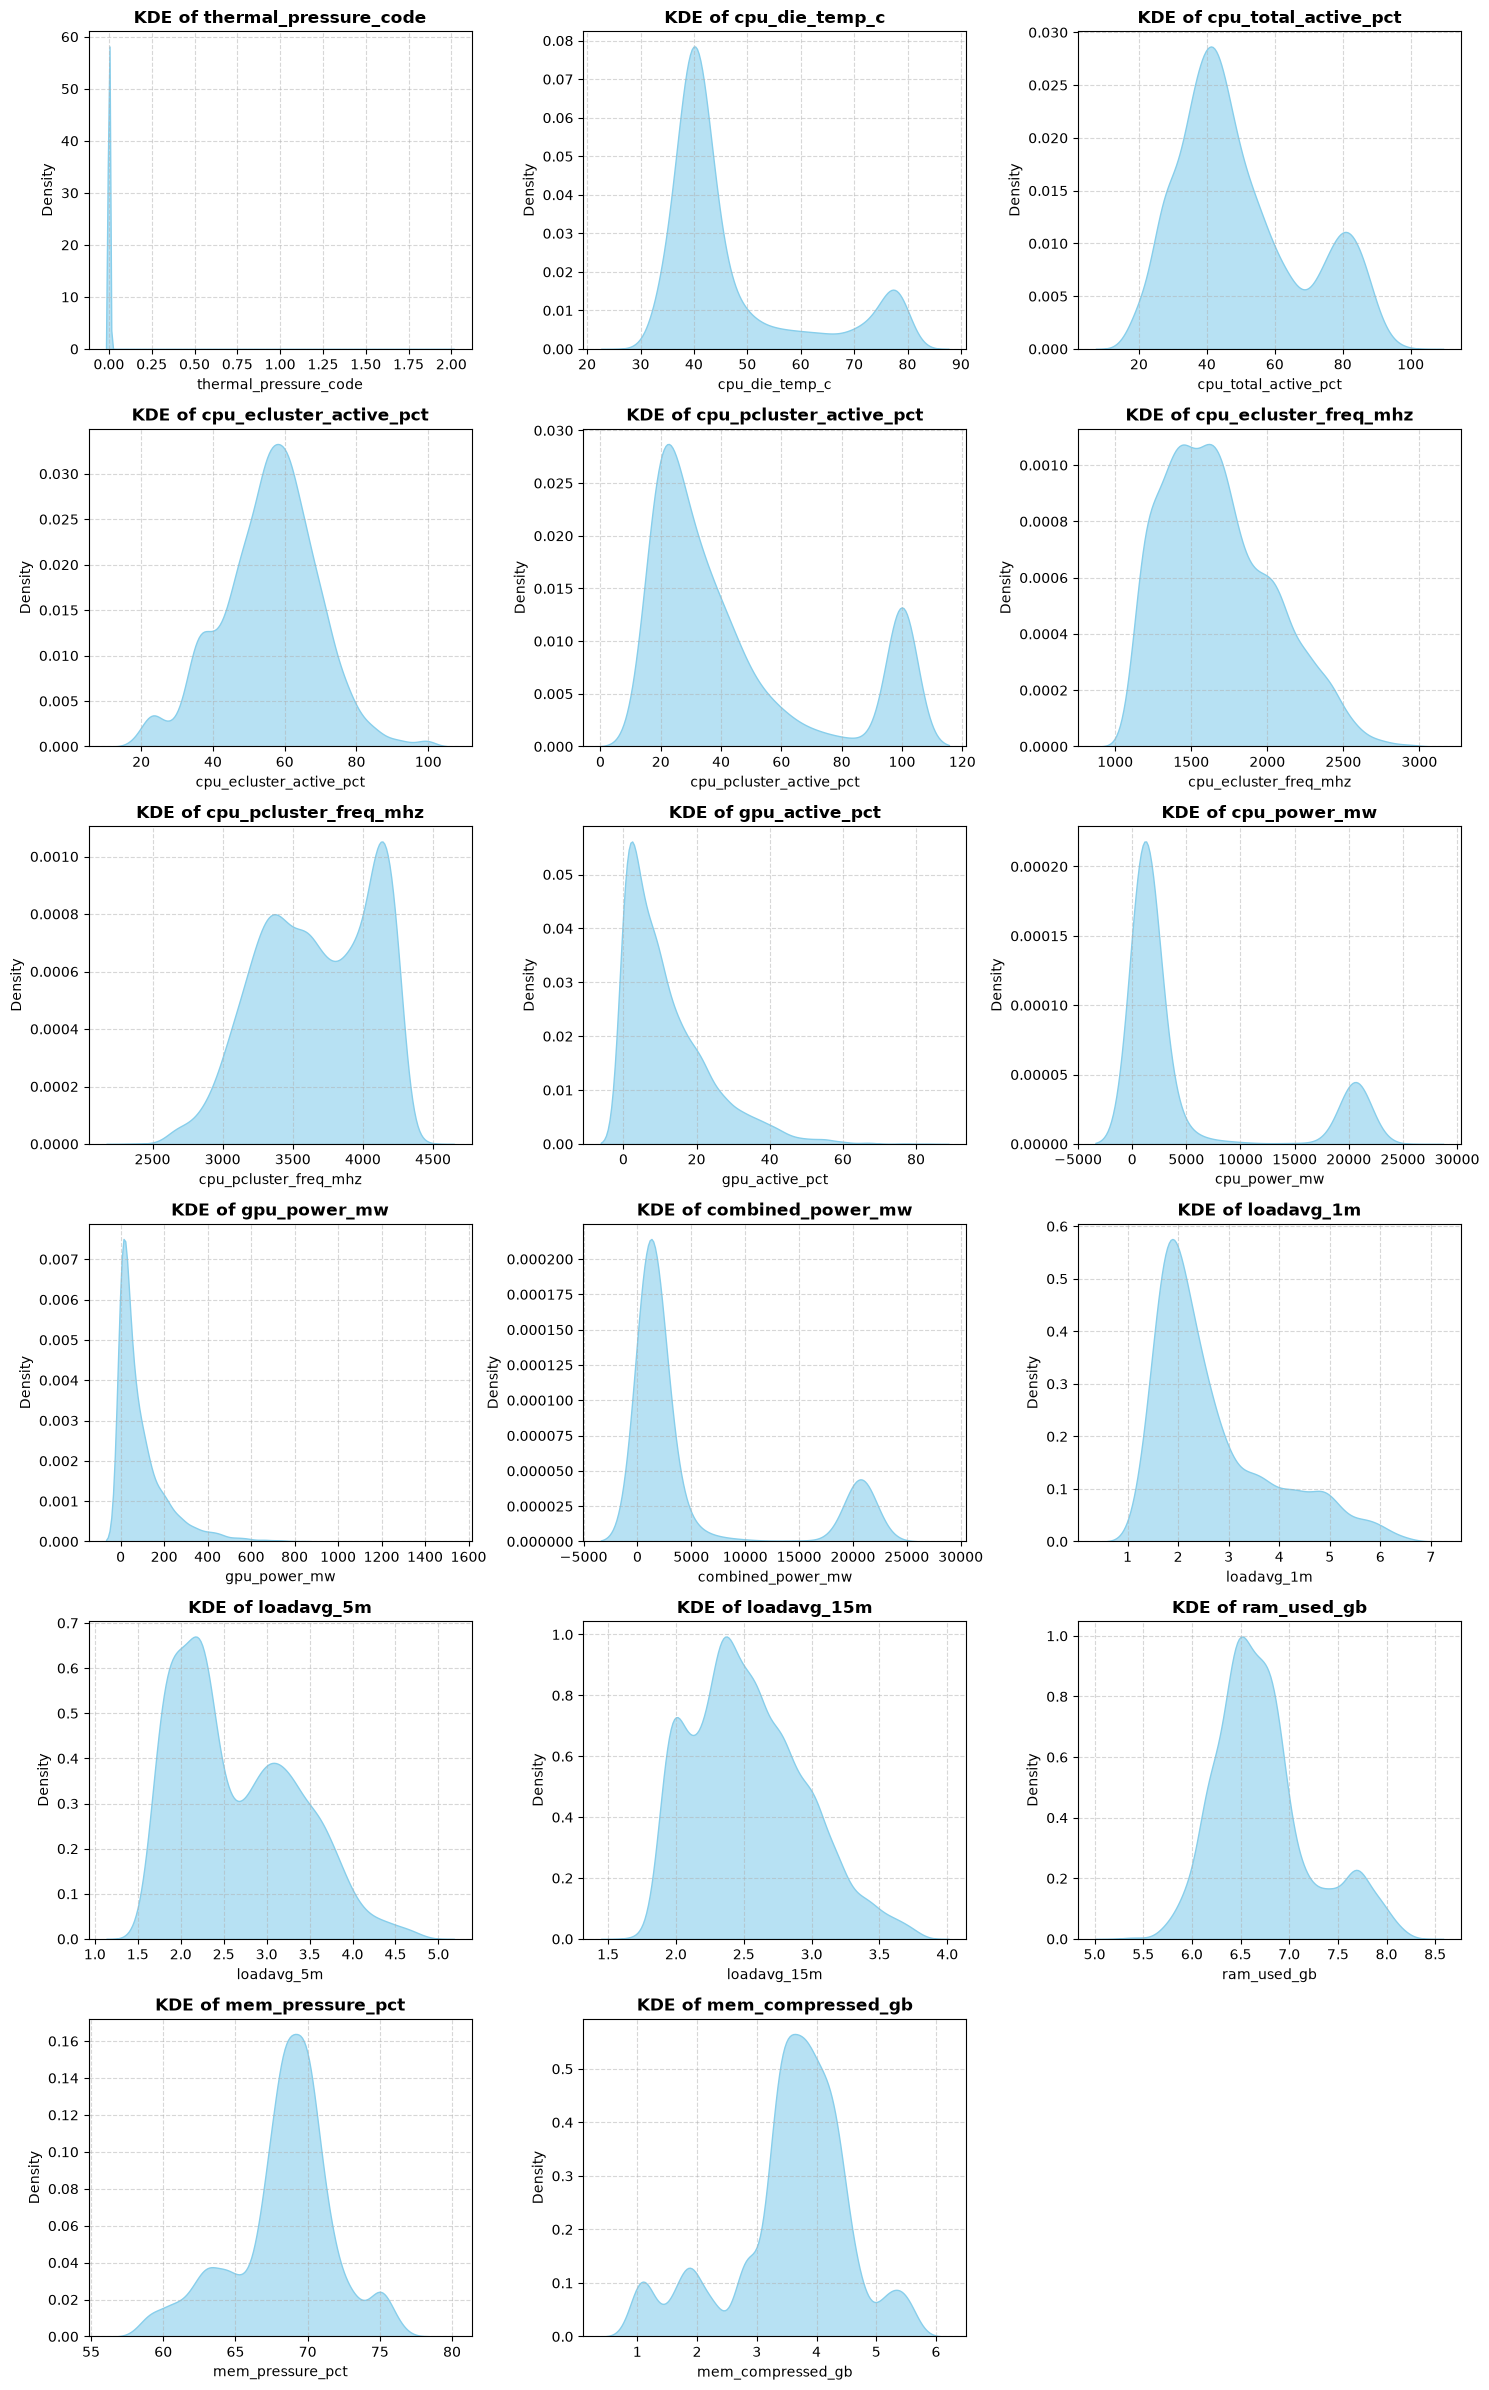

In [140]:
plot_numeric_kdes(df_final)

2026-06-27 03:26:58,185 [WARNING] The following requested columns were missing from the DataFrame and will be skipped: ['cpu_power_mw_is_outlier']
2026-06-27 03:26:58,185 [INFO] Generating pairplot for 8 features...


Notice: No specific columns provided. The pairplot defaults to:
  - mem_compressed_gb
  - cpu_pcluster_freq_mhz
  - cpu_power_mw
  - loadavg_1m
  - cpu_pcluster_active_pct
  - cpu_total_active_pct
  - combined_power_mw
  - cpu_power_mw_is_outlier
  - cpu_ecluster_freq_mhz



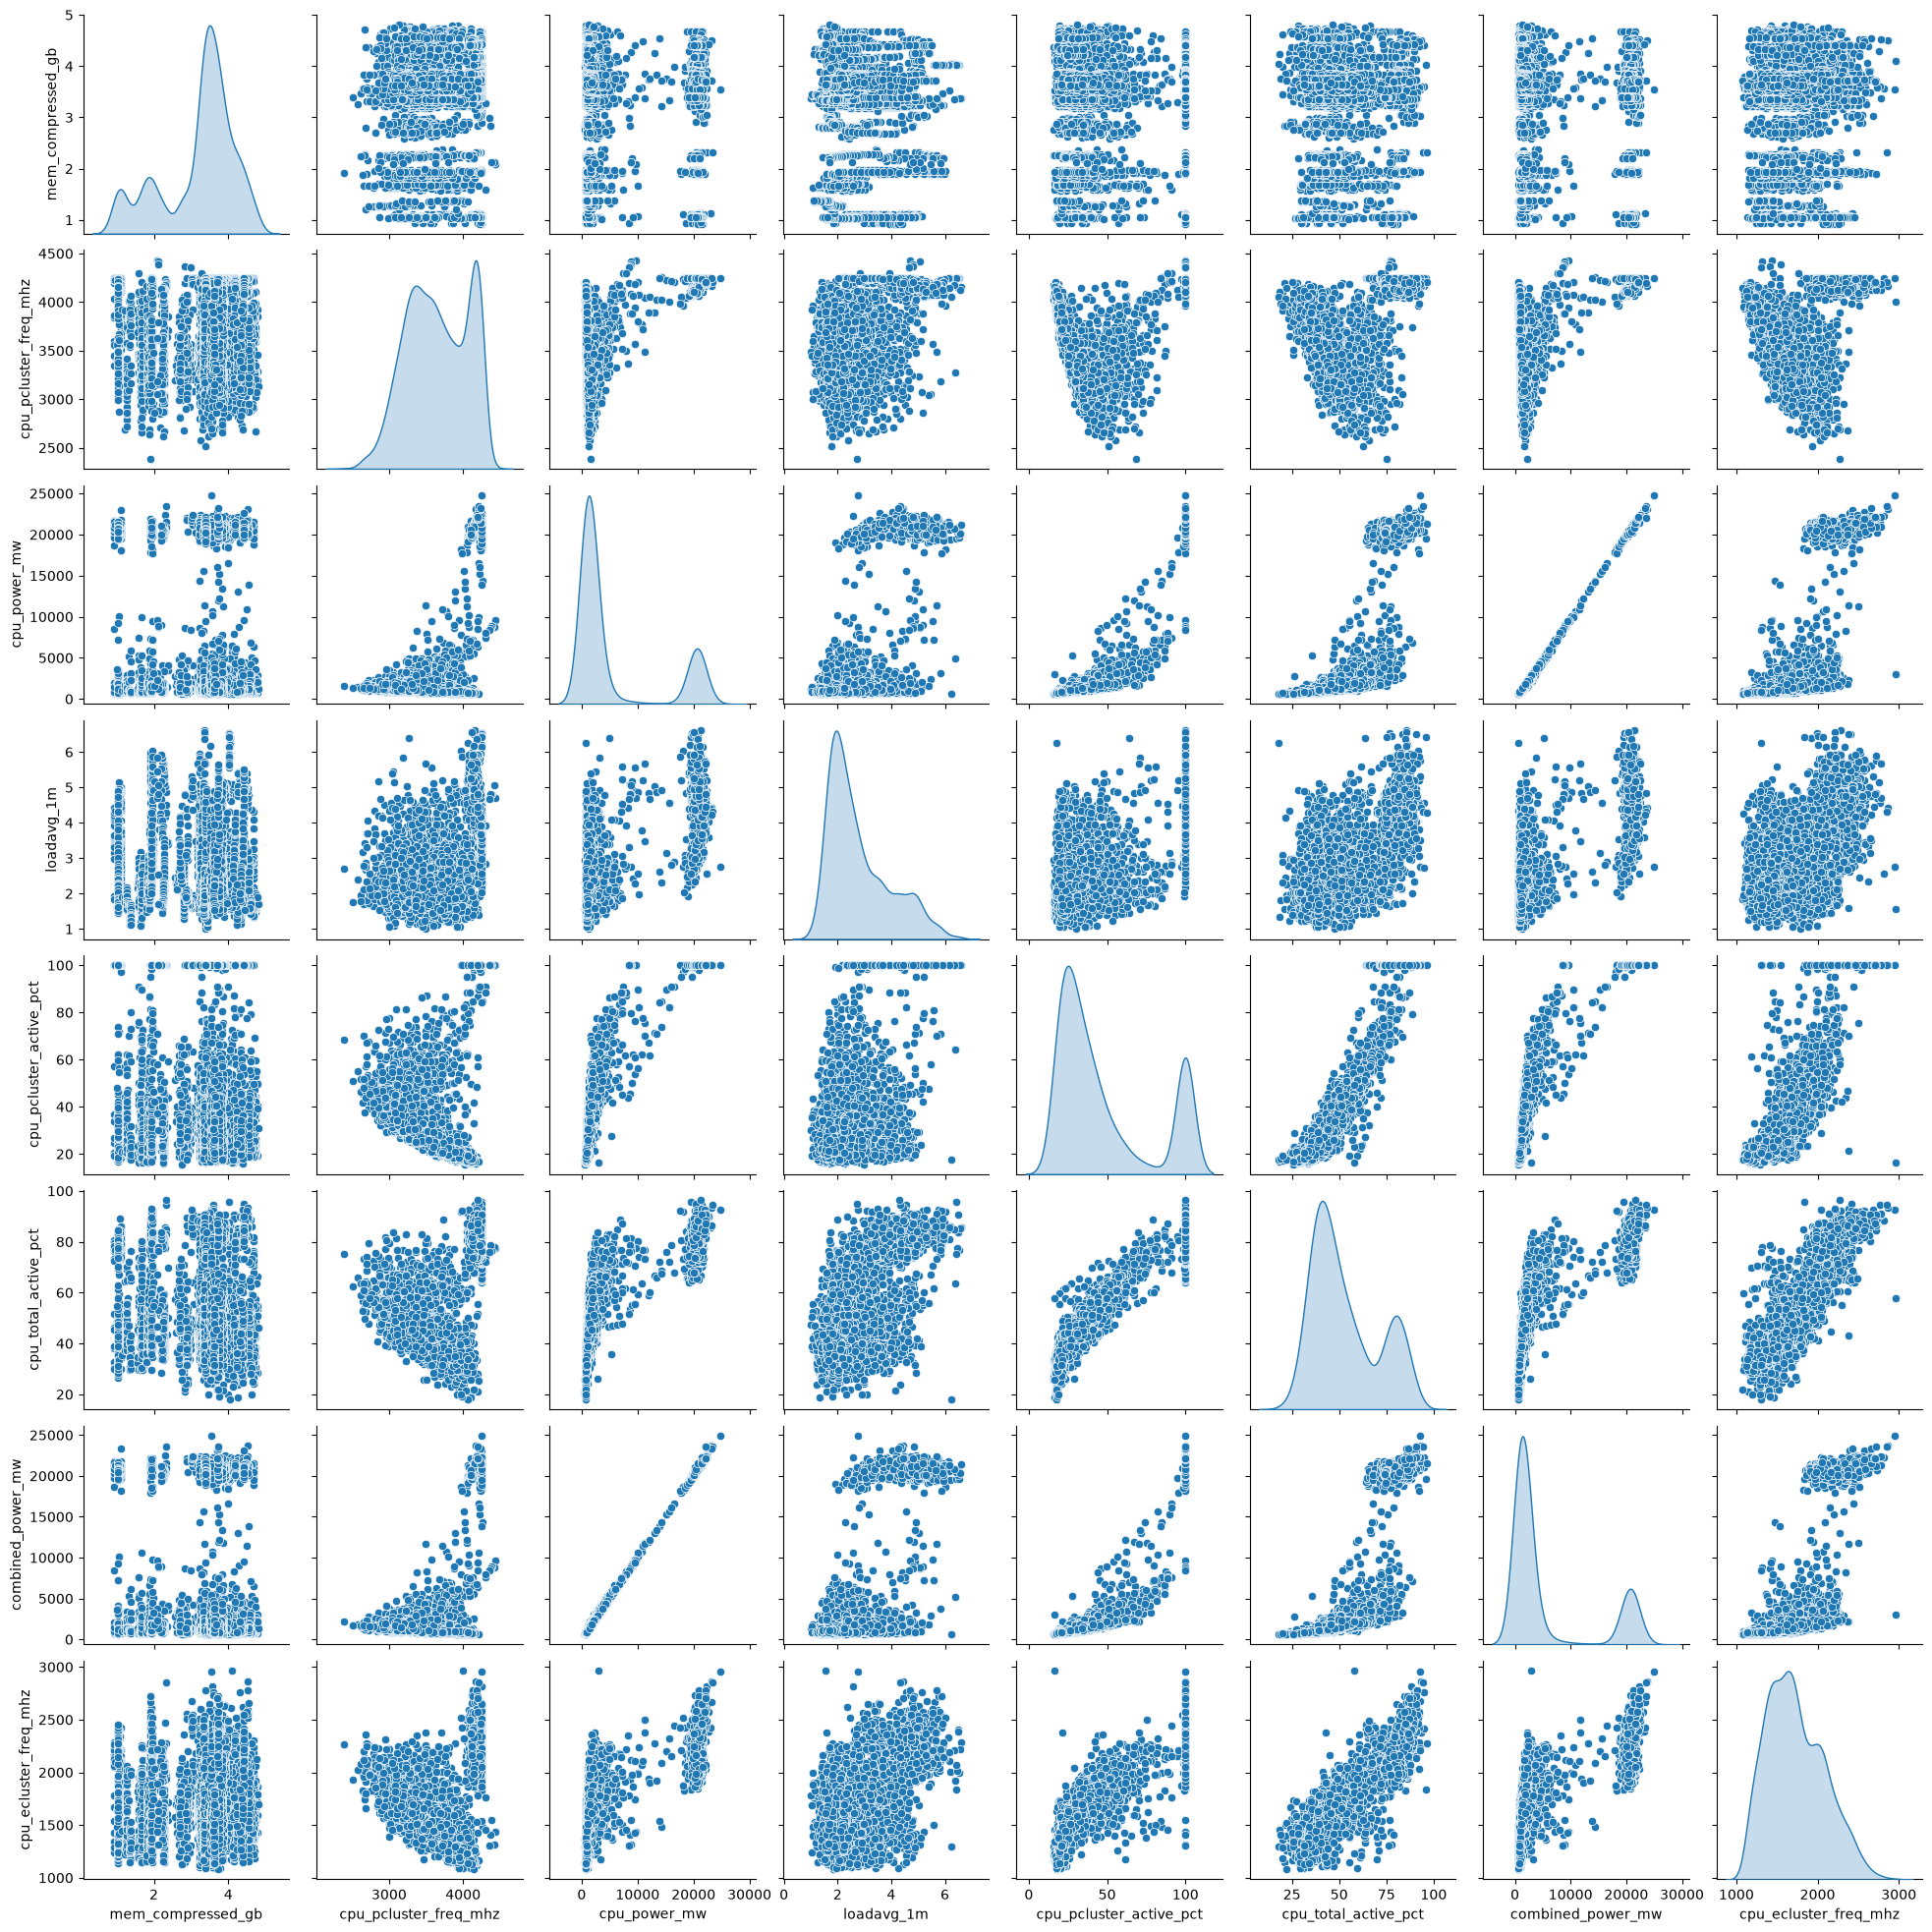

In [43]:
plot_variable_pairplot(df_final)

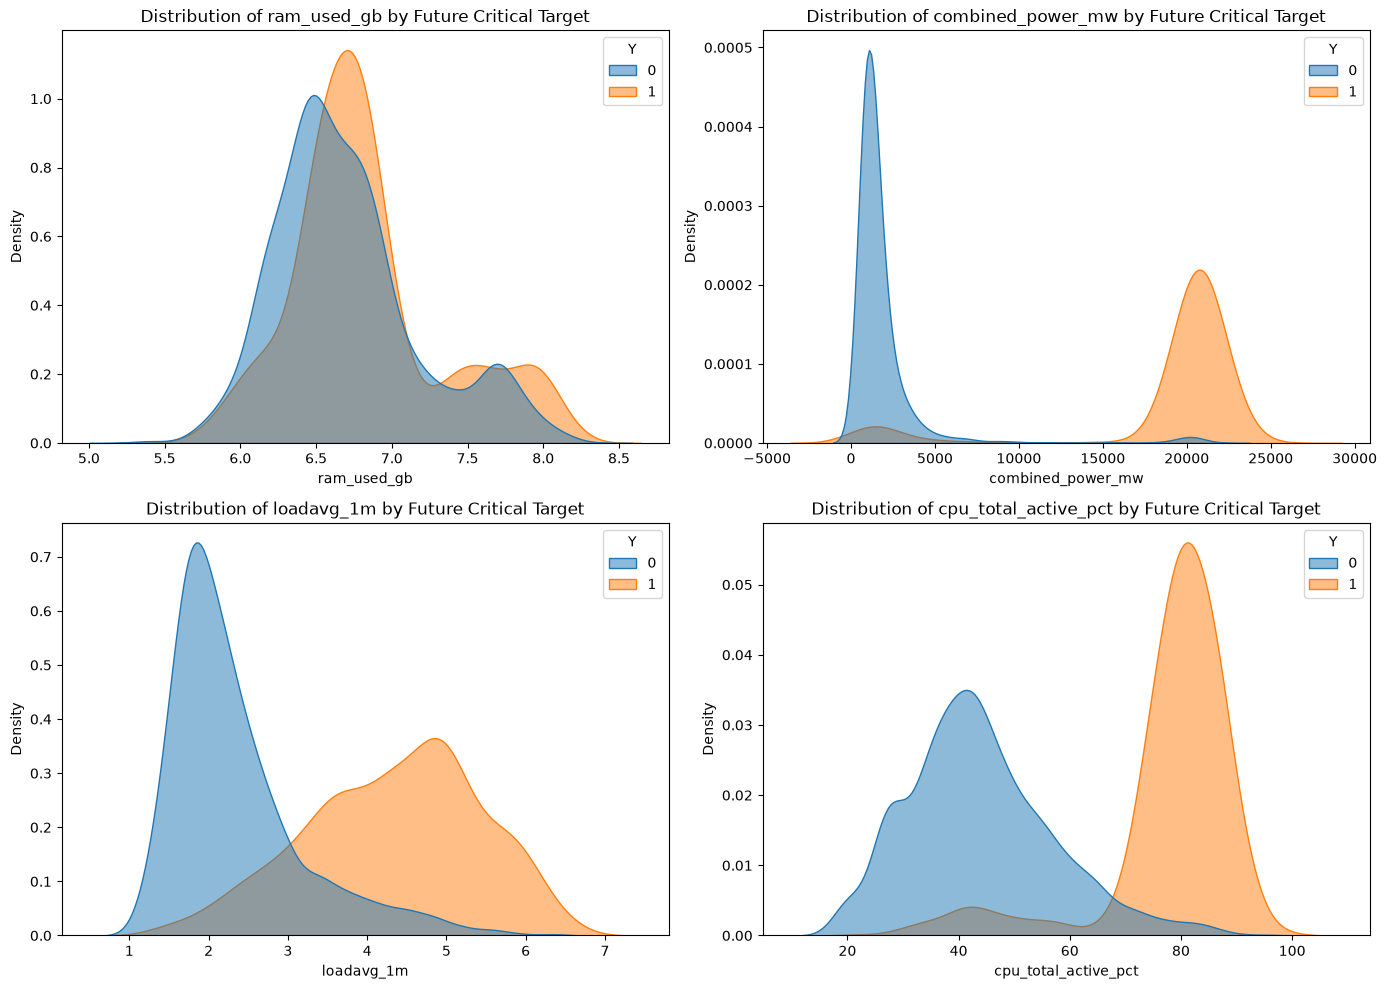

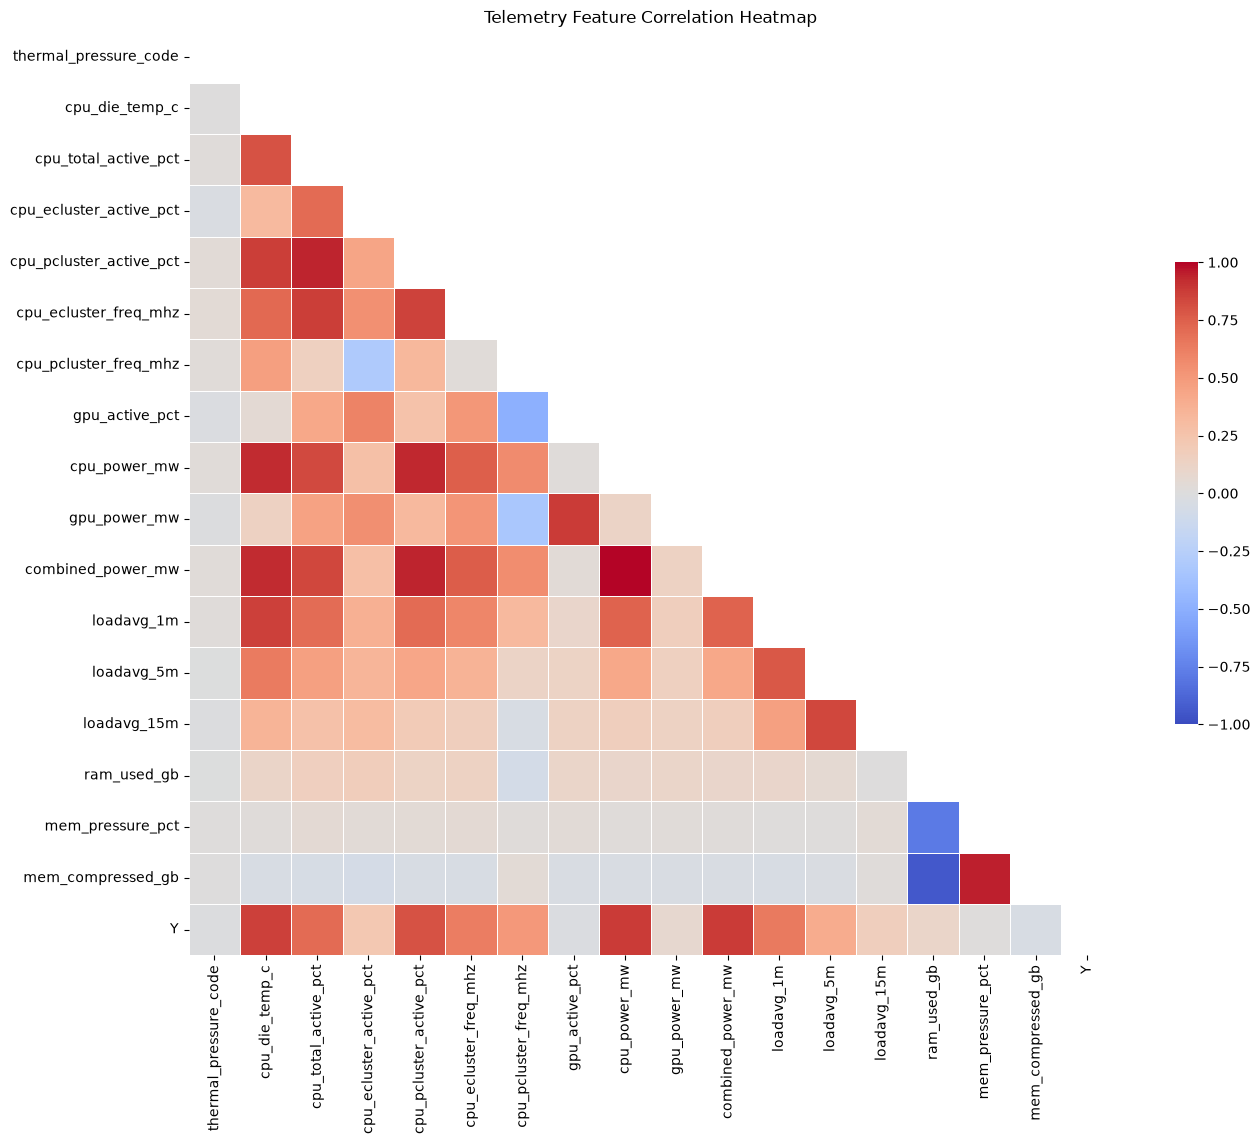


--- Multicollinearity Warnings (r > 0.85) ---
Feature 'cpu_pcluster_active_pct' is highly correlated with ['cpu_die_temp_c', 'cpu_total_active_pct']. Consider dropping for linear models.
Feature 'cpu_ecluster_freq_mhz' is highly correlated with ['cpu_total_active_pct', 'cpu_pcluster_active_pct']. Consider dropping for linear models.
Feature 'cpu_power_mw' is highly correlated with ['cpu_die_temp_c', 'cpu_pcluster_active_pct']. Consider dropping for linear models.
Feature 'gpu_power_mw' is highly correlated with ['gpu_active_pct']. Consider dropping for linear models.
Feature 'combined_power_mw' is highly correlated with ['cpu_die_temp_c', 'cpu_pcluster_active_pct', 'cpu_power_mw']. Consider dropping for linear models.
Feature 'loadavg_1m' is highly correlated with ['cpu_die_temp_c']. Consider dropping for linear models.
Feature 'mem_compressed_gb' is highly correlated with ['ram_used_gb', 'mem_pressure_pct']. Consider dropping for linear models.
Feature 'Y' is highly correlated with [

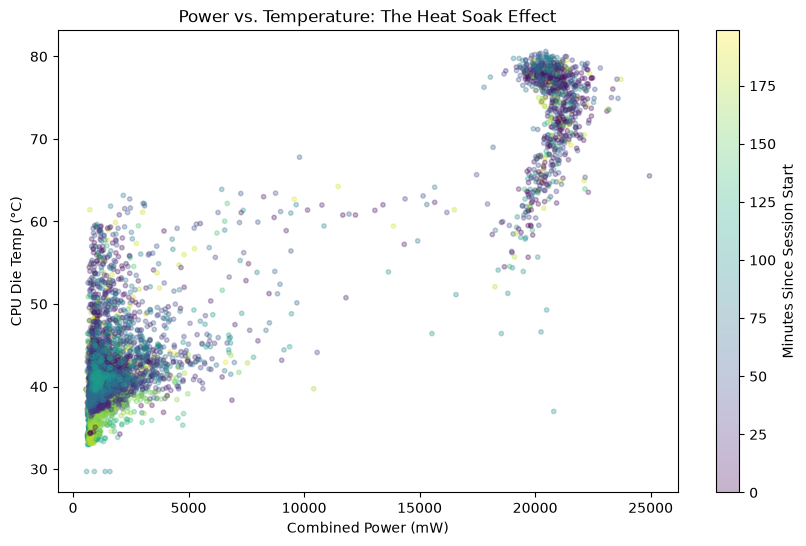

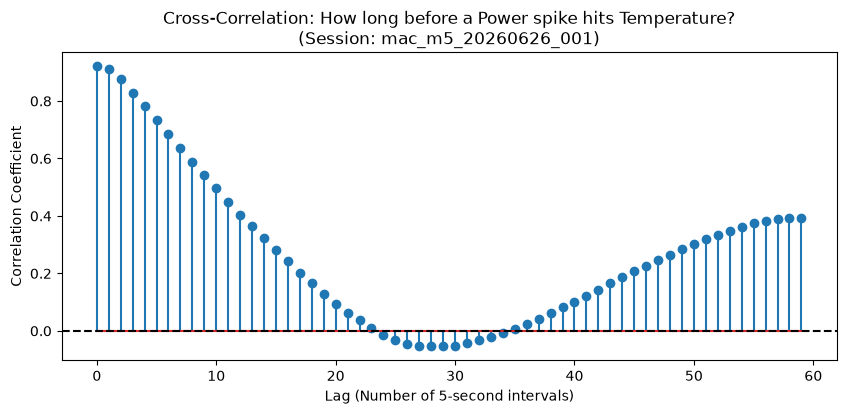


Maximum correlation occurs at a lag of 0 intervals (0 seconds).


In [147]:
plot_univariate_distributions(df_final, target_col="Y")
plot_correlation_heatmap(df_final)
test_heat_soak_assumption(df_final)
plot_power_temp_crosscorr_eda(df_final)

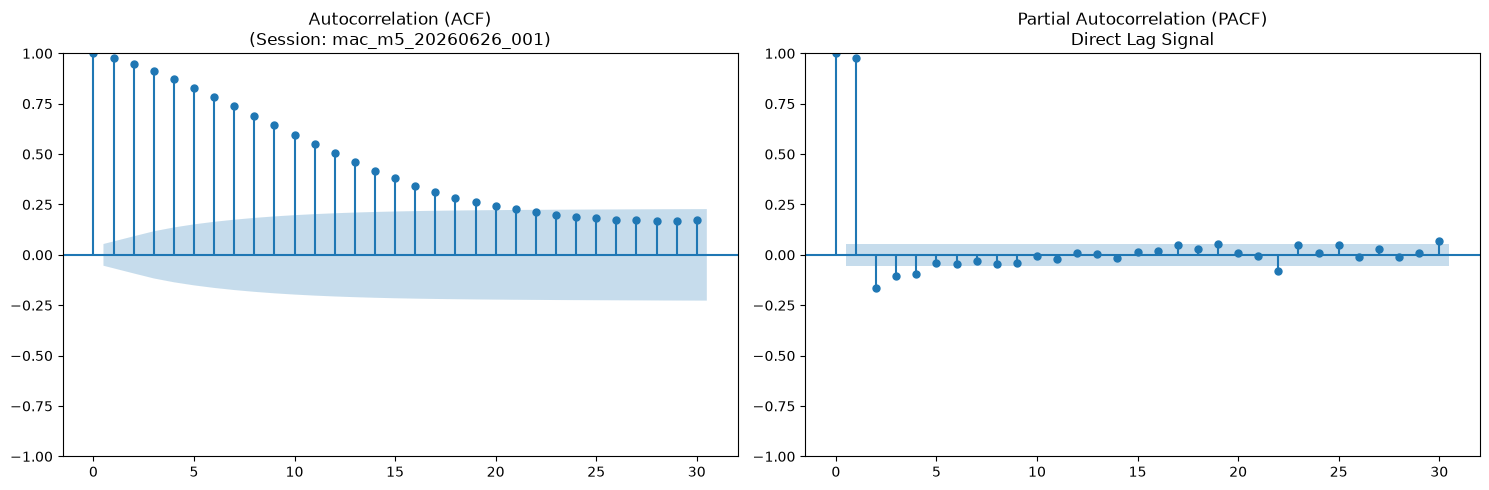


💡 INTERPRETATION:
Look at the PACF plot (right). The point where the stems fall inside the blue shaded area
is where historical data stops providing *new* direct information. Use this to set your max lag features.


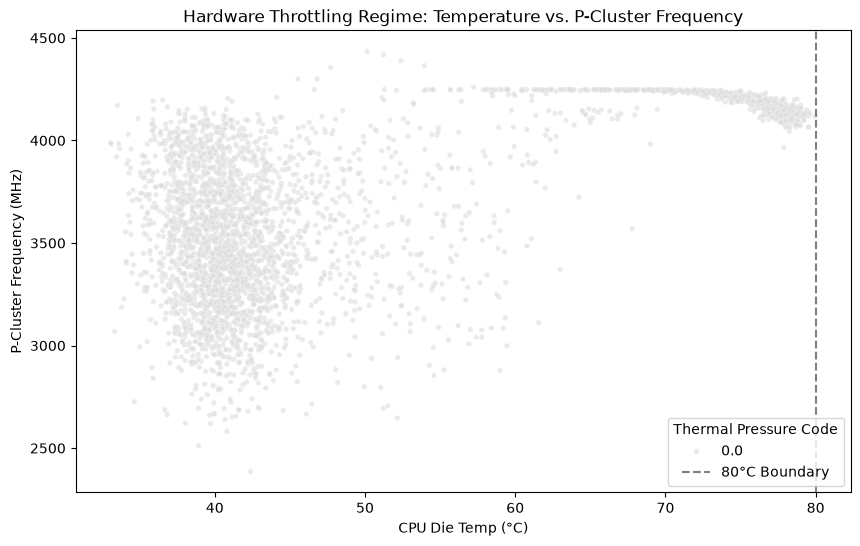

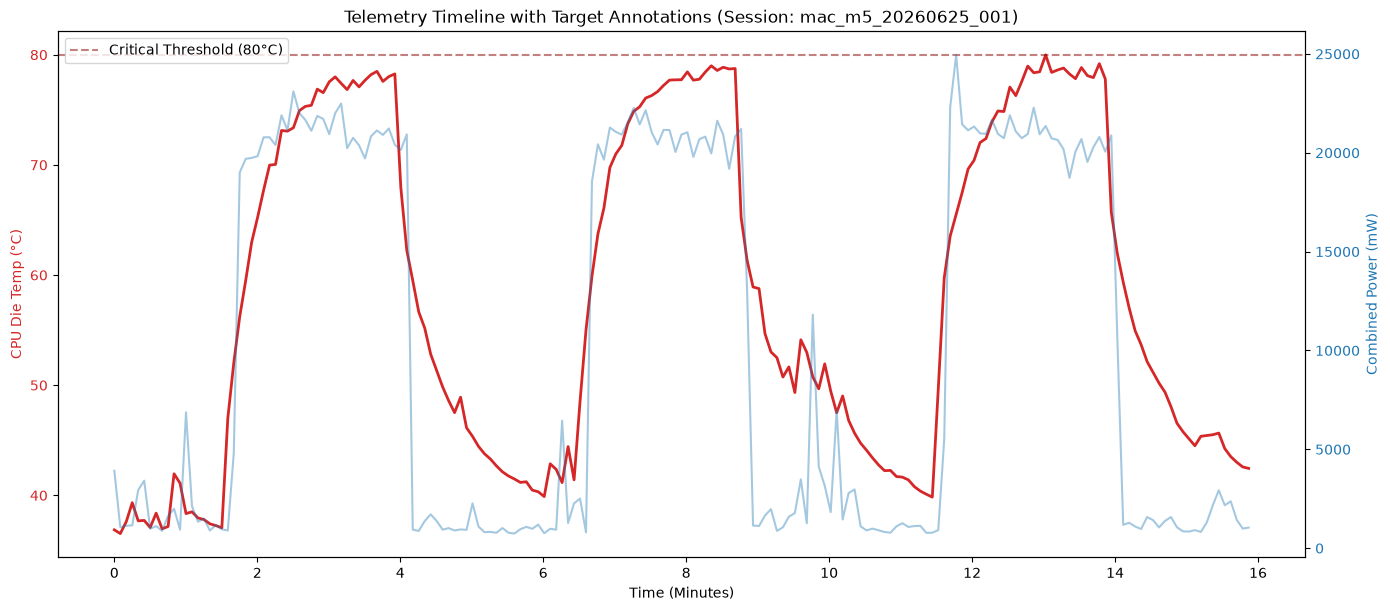


--- Baseline Target Signal (Mutual Information) ---
combined_power_mw              0.3774
cpu_power_mw                   0.3747
cpu_pcluster_active_pct        0.3693
cpu_pcluster_freq_mhz          0.3387
cpu_total_active_pct           0.3302
mem_compressed_gb              0.2903
cpu_ecluster_freq_mhz          0.2512
loadavg_1m                     0.1998
loadavg_5m                     0.0875
gpu_power_mw                   0.0493

💡 Note: Features with high MI scores are your strongest baseline predictors.


In [46]:
plot_autocorrelation(df_final, target_col="cpu_die_temp_c", lags=30)
plot_throttling_regime(df_final)
plot_annotated_timeline(df_final, session_idx=0)
calculate_baseline_target_importance(df_final, target_col="Y")

In [162]:
from data_features import engineer_features, drop_invalid_rows

df_features = engineer_features(df_final)
df_ml_ready = drop_invalid_rows(df_features)

2026-06-27 09:16:15,833 [INFO] Engineering features grouped by session_id.
2026-06-27 09:16:15,859 [INFO] Feature engineering complete.
2026-06-27 09:16:15,861 [INFO] Dropped 145 boundary rows with invalid feature history.


In [ ]:
# drop cpu_die_temp_c because it is used to construct the target variable Y
df_ml_ready = df_ml_ready.drop(columns=["cpu_die_temp_c"])

In [164]:
# compute the correlation highest with the target variable Y
TARGET_COL = "Y"
correlations = df_ml_ready.select_dtypes(include="number").corr()[TARGET_COL].abs().sort_values(ascending=False)

# set display options to all rows
pd.set_option('display.max_rows', None)
# display correlations as pd.Series
display(correlations)

Y                                         1.000000
pcluster_power_pressure                   0.878008
cpu_power_mw                              0.874310
combined_power_mw                         0.873608
cpu_power_mw_lag_1                        0.838470
combined_power_mw_lag_1                   0.837780
cpu_die_temp_c_lag_1                      0.820479
cpu_power_mw_roll_mean_30s                0.811346
combined_power_mw_roll_mean_30s           0.811002
cpu_power_mw_lag_2                        0.799813
combined_power_mw_lag_2                   0.799120
cpu_pcluster_active_pct                   0.786683
combined_power_mw_roll_min_30s            0.786033
cpu_power_mw_roll_min_30s                 0.785981
cpu_die_temp_c_lag_2                      0.778258
cpu_power_mw_roll_max_30s                 0.776944
combined_power_mw_roll_max_30s            0.776102
cpu_pcluster_active_pct_roll_min_30s      0.775336
cpu_die_temp_c_roll_mean_30s              0.766993
cpu_die_temp_c_roll_min_30s    

In [165]:
df_ml_ready.shape

(5009, 140)

In [ ]:
from data_prep import chronological_session_split_raw, separate_raw

train_df, val_df, test_df = chronological_session_split_raw(df_ml_ready)

X_train, y_train, meta_train = separate_raw(train_df)
X_val, y_val, meta_val = separate_raw(val_df)
X_test, y_test, meta_test = separate_raw(test_df)

rf, gb, rf_imp, gb_imp = fit_tree_importance(X_train, y_train, X_train.columns)

print("RF top 20")
display(rf_imp.head(20))

print("GB top 20")
display(gb_imp.head(20))

perm_imp, perm_std = get_permutation_importance(rf, X_val, y_val, X_val.columns, scoring="f1")
print("Permutation top 20 - Random Forest")
display(perm_imp.head(20))

print("Permutation top 20 - Gradient Boosting")
perm_imp_gb, perm_std_gb = get_permutation_importance(gb, X_val, y_val, X_val.columns, scoring="f1")
display(perm_imp_gb.head(20))

RF top 20


combined_power_mw                        0.072808
cpu_power_mw                             0.071063
cpu_total_active_pct                     0.070429
pcluster_power_pressure                  0.063536
cpu_pcluster_active_pct                  0.048894
cpu_die_temp_c_lag_1                     0.042335
combined_power_mw_lag_1                  0.040692
cpu_power_mw_lag_1                       0.035364
combined_power_mw_roll_max_30s           0.035129
cpu_pcluster_active_pct_lag_1            0.030056
cpu_die_temp_c_diff_6                    0.029160
cpu_die_temp_c_roll_max_30s              0.027623
cpu_power_mw_roll_max_30s                0.026923
combined_power_mw_roll_mean_30s          0.023717
thermal_distress_proxy                   0.022505
cpu_die_temp_c_diff_1                    0.019938
cpu_die_temp_c_lag_2                     0.019705
cpu_pcluster_active_pct_roll_mean_30s    0.015967
cpu_power_mw_roll_mean_30s               0.012336
cpu_pcluster_active_pct_lag_2            0.011539


GB top 20


cpu_power_mw                           0.377270
combined_power_mw                      0.313853
cpu_die_temp_c_diff_6                  0.103494
pcluster_power_pressure                0.096497
cpu_pcluster_freq_mhz_roll_std_5m      0.036138
cpu_die_temp_c_diff_1                  0.011370
cpu_die_temp_c_roll_min_30s            0.006932
cpu_die_temp_c_roll_min_5m             0.005369
cpu_die_temp_c_roll_std_1m             0.003957
cpu_die_temp_c_lag_10                  0.003931
cpu_die_temp_c_roll_mean_15m           0.003344
cpu_die_temp_c_roll_mean_1m            0.003183
cpu_die_temp_c_roll_min_1m             0.002835
cpu_die_temp_c_roll_range_1m           0.002798
cpu_total_active_pct                   0.002306
cpu_power_mw_roll_max_5m               0.002301
loadavg_5m                             0.002022
cpu_die_temp_c_roll_max_1m             0.001911
cpu_pcluster_freq_mhz_roll_range_5m    0.001760
cpu_die_temp_c_lag_5                   0.001187
dtype: float64

Permutation top 20 - Random Forest


thermal_distress_proxy             0.118515
cpu_total_active_pct               0.117713
cpu_die_temp_c_lag_1               0.116598
cpu_power_mw                       0.116587
cpu_die_temp_c_roll_max_30s        0.115423
combined_power_mw                  0.109485
pcluster_power_pressure            0.109485
cpu_pcluster_active_pct            0.109485
combined_power_mw_roll_max_30s     0.106015
cpu_die_temp_c_roll_max_1m         0.104899
combined_power_mw_roll_max_1m      0.091841
cpu_ecluster_freq_mhz              0.090591
combined_power_mw_lag_1            0.090241
cpu_power_mw_lag_1                 0.090241
cpu_power_mw_roll_range_5m         0.086827
cpu_power_mw_roll_max_5m           0.086817
combined_power_mw_roll_max_5m      0.080842
cpu_power_mw_roll_mean_5m          0.080070
combined_power_mw_roll_mean_30s    0.064072
cpu_die_temp_c_lag_2               0.060749
dtype: float64

Permutation top 20 - Gradient Boosting


cpu_die_temp_c_diff_6                     0.149154
cpu_power_mw_roll_min_1m                  0.132893
cpu_power_mw_lag_3                        0.030409
cpu_die_temp_c_roll_range_5m              0.019691
cpu_total_active_pct                      0.014333
cpu_die_temp_c_roll_min_5m                0.011949
cpu_die_temp_c_diff_1                     0.009826
cpu_power_mw_roll_max_5m                  0.007328
cpu_die_temp_c_roll_min_30s               0.006920
cpu_pcluster_active_pct_roll_mean_30s     0.000000
cpu_pcluster_active_pct_roll_std_30s      0.000000
cpu_pcluster_active_pct_roll_max_30s      0.000000
cpu_power_mw_roll_range_1m                0.000000
cpu_pcluster_active_pct_roll_range_30s    0.000000
cpu_power_mw_roll_range_5m                0.000000
cpu_power_mw_roll_min_5m                  0.000000
cpu_power_mw_roll_std_5m                  0.000000
cpu_pcluster_active_pct_roll_min_30s      0.000000
cpu_power_mw_roll_mean_5m                 0.000000
cpu_pcluster_active_pct_roll_st

In [173]:
from data_features import aggregate_family_importance
print("\n--- RF permutation importance by feature family ---")
display(aggregate_family_importance(perm_imp))

# Step 5 — identify features safe to drop
# Negative permutation importance means the feature HURTS the model
safe_to_drop = perm_imp[perm_imp <= 0].index.tolist()
low_contribution = perm_imp[(perm_imp > 0) & (perm_imp < 0.002)].index.tolist()

print(f"\nSafe to drop (perm imp <= 0): {len(safe_to_drop)}")
print(safe_to_drop)
print(f"\nLow contribution (perm imp < 0.002): {len(low_contribution)}")


--- RF permutation importance by feature family ---


family
rolling        1.180060
lag            0.490384
raw_core       0.358167
interaction    0.228001
other          0.215414
diff           0.113749
accel          0.006800
Name: importance, dtype: float64


Safe to drop (perm imp <= 0): 74
['cpu_pcluster_active_pct_roll_range_5m', 'cpu_pcluster_active_pct_roll_std_5m', 'cpu_pcluster_active_pct_roll_min_5m', 'cpu_pcluster_active_pct_roll_max_5m', 'cpu_pcluster_freq_mhz_lag_10', 'mem_compressed_gb', 'cpu_pcluster_active_pct_roll_range_1m', 'cpu_pcluster_freq_mhz_roll_mean_30s', 'cpu_pcluster_active_pct_roll_max_1m', 'cpu_pcluster_active_pct_roll_mean_1m', 'cpu_pcluster_active_pct_roll_range_30s', 'cpu_pcluster_active_pct_roll_min_30s', 'cpu_pcluster_active_pct_roll_min_1m', 'cpu_pcluster_freq_mhz_roll_mean_1m', 'cpu_pcluster_freq_mhz_roll_std_30s', 'cpu_pcluster_freq_mhz_roll_min_30s', 'cpu_pcluster_freq_mhz_roll_range_30s', 'cpu_pcluster_active_pct_roll_std_30s', 'cpu_pcluster_freq_mhz_roll_std_1m', 'mem_pressure_pct', 'cpu_pcluster_freq_mhz_roll_min_1m', 'cpu_pcluster_freq_mhz_roll_range_1m', 'cpu_pcluster_freq_mhz_roll_mean_5m', 'cpu_pcluster_freq_mhz_roll_mean_15m', 'ram_used_gb', 'cpu_power_mw_accel', 'loadavg_15m', 'cpu_pcluster_freq

In [174]:
KEEP_COLS = [
    "pcluster_power_pressure",
    "cpu_power_mw",
    "combined_power_mw",
    "combined_power_mw_is_high",
    "cpu_pcluster_active_pct",
    "cpu_die_temp_c_lag_1",
    "cpu_total_active_pct",
    "combined_power_mw_roll_max_30s",
    "cpu_die_temp_c_roll_max_30s",
    "cpu_power_mw_is_high",
    "combined_power_mw_lag_1",
    "cpu_pcluster_active_pct_lag_1",
    "cpu_die_temp_c_diff_6",
    "cpu_power_mw_lag_1",
    "cpu_die_temp_c_diff_1",
    "combined_power_mw_roll_mean_30s",
    "thermal_distress_proxy",
    "cpu_power_mw_roll_max_30s",
    "cpu_pcluster_active_pct_roll_max_30s",
    "cpu_ecluster_freq_mhz",
    "cpu_die_temp_c_roll_mean_30s",
    "loadavg_5m",
    "cpu_pcluster_freq_mhz",
    "ram_used_gb",
]

keep_all = ["session_id", "timestamp_utc", "Y"] + KEEP_COLS
df_final_model = df_ml_ready[[c for c in keep_all if c in df_ml_ready.columns]].copy()
splits = build_ml_splits(df_final_model)

X_train, y_train, meta_train = splits["train"]
X_val, y_val, meta_val = splits["val"]
X_test, y_test, meta_test = splits["test"]
bundle = splits["bundle"]

2026-06-27 09:33:32,205 [INFO] Chronological session split — train 70% / val 15% / test 15%.
2026-06-27 09:33:32,212 [INFO] Sessions assigned — train: 3, val: 1, test: 1.
2026-06-27 09:33:32,223 [INFO] Column routing — passthrough: 0, multimodal_base: 7, multimodal_children: 10, diff/accel (YJ): 2, box-cox: 3, yj-fallback: 0
2026-06-27 09:33:32,249 [INFO] Box-Cox fitted on 3 columns.
2026-06-27 09:33:32,257 [INFO] Yeo-Johnson fitted on 2 columns (2 diff/accel + 0 other fallback).
2026-06-27 09:33:32,262 [INFO] Preprocessing bundle saved to artifacts/preprocessors.joblib.
2026-06-27 09:33:32,263 [INFO] Transforming X_train...
2026-06-27 09:33:32,268 [INFO] Transforming X_val...
2026-06-27 09:33:32,272 [INFO] Transforming X_test...


In [175]:
X_train.shape

(3189, 29)

In [176]:
X_train.head()

,pcluster_power_pressure,cpu_power_mw,combined_power_mw,cpu_pcluster_active_pct,cpu_die_temp_c_lag_1,cpu_total_active_pct,combined_power_mw_roll_max_30s,cpu_die_temp_c_roll_max_30s,combined_power_mw_lag_1,cpu_pcluster_active_pct_lag_1,cpu_die_temp_c_diff_6,cpu_power_mw_lag_1,cpu_die_temp_c_diff_1,combined_power_mw_roll_mean_30s,thermal_distress_proxy,cpu_power_mw_roll_max_30s,cpu_pcluster_active_pct_roll_max_30s,cpu_ecluster_freq_mhz,cpu_die_temp_c_roll_mean_30s,loadavg_5m,cpu_pcluster_freq_mhz,ram_used_gb,cpu_power_mw_is_high,combined_power_mw_is_high,cpu_pcluster_active_pct_is_high,cpu_total_active_pct_is_high,loadavg_5m_is_high,cpu_pcluster_freq_mhz_is_high,ram_used_gb_is_high
0,1.643172,12.121683,10.876453,2.415017,3.630927,1.356708,4.991748,2.689586,11.220509,2.398072,1.454313,12.481916,-0.055394,11.031481,1.441230,5.056618,1.39776,1.436895,3.093744,0.262768,0.756949,0.179821,1,1,1,1,1,0,0
1,1.655553,13.107942,11.952052,2.415017,3.624269,1.976320,5.301020,2.711361,10.811302,2.398072,1.187682,12.078460,0.134289,11.343363,1.456276,5.303210,1.39776,2.022670,3.238759,0.280890,0.755491,0.165628,1,1,1,1,1,0,0
2,1.647694,12.470032,11.347120,2.415017,3.659192,1.833804,5.301020,2.845688,11.880467,2.398072,1.063470,13.061233,0.802194,11.459476,1.547092,5.303210,1.39776,1.743677,3.367566,0.327018,0.716283,0.138424,1,1,1,1,1,0,0
3,1.645677,12.313062,11.160157,2.415017,3.833553,1.692225,5.301020,2.879560,11.279154,2.398072,0.804822,12.425577,0.176268,11.542947,1.561082,5.303210,1.39776,1.618364,3.462835,0.344316,0.721874,-0.033069,1,1,1,1,1,0,0
4,1.640861,11.948663,10.859033,2.415017,3.877520,1.754454,5.301020,2.887545,11.093309,2.398072,0.808141,12.269162,0.021554,11.611448,1.572402,5.303210,1.39776,1.442092,3.558532,0.375206,0.708348,0.066076,1,1,1,1,1,0,0
